Submit your answers to gradescope before or at the latest at 12:50pm.

In [1]:
using Plots

In [2]:
using SymPy

In [3]:
using FastGaussQuadrature

In [4]:
using NLsolve

# Question 1

Experience has shown that 6\% of customers who make reservations
for a restaurant with 20 tables do not show up.

How many more reservations can the restaurant accept and be able
to give everybody who shows up a table with 90\% confidence?

## answer to question 1

We apply the binomial distribution.

In [5]:
c(n,k) = factorial(n)/(factorial(k)*factorial(n-k))
f(n) = sum([c(big(n),big(k))*((94/100)^k)*((4/100)^(n-k)) for k=0:19])

f (generic function with 1 method)

The function ``f(n)`` gives the probability that **not** all 20 tables are occupied.

In [6]:
for n=20:24
    println(n, ": ", f(n))
end

20: 0.3775017306236322695474394676061501508837123575201014606188838732137063697638269
21: 0.1378667031059904123915053535900890400483630975796435726839118717882948353069729
22: 0.03763367202369953607724637094980651436733237445176038187176837156724172791764408
23: 0.00828812745730869555387131760092324938064864509848971778255057691875047326453888
24: 0.001546004549201647255970317668307509972173611203169369596951141122311275113222475


If we do not accept more than 20 reservations, then we have a 56% probability of an empty table.  With 22, this probability drops to 6%.  Alternatively, accepting 2 more reservations, gives a 94% probability of all 20 tables to be occupied.

# Question 2

Consider the following transfer function

$$
   H(z) = \frac{3 z - 2}{z^2 - (7/3)z + 2/3}.
$$
Is the filter with this transfer function $H$ stable?

In your justification of your answer, refer to the definition
of a stable filter.

## answer to question 2

A filter with transfer function $H$ is stable if the absolute value its coefficients $h_k$ of its z-transform are all strictly less than 1: $|h_k| < 1$ for all $k$.

We look at the poles of $H(z)$, the roots of the denominator.

In [7]:
z = Sym("z")

z

In [8]:
q = z^2 - (7/3)*z + 2/3
roots(q)

Dict{Sym{PyCall.PyObject}, Sym{PyCall.PyObject}} with 2 entries:
  0.333333333333333 => 1
  2.00000000000000  => 1

We see that one of the roots is larger than 1, that is: 2.
If we apply a partial fraction decomposition, then we have one term where $z-2$ appears in the denominator
and then consider the expansion:
$$
   \frac{1}{2 - z} = \sum_{k=0}^\infty 2^k z^k,
$$
or equivalently:
$$
   \frac{-z}{1 - 2 z^{-1}} = -z \sum_{k=0}^\infty 2^k z^{-k}.
$$

As $2^k$ grows exponentially large, we have one component in the decomposition of $H$ where the coefficients are larger than 1 in absolute value, so the filter is not stable.

# Question 3

Let $f(x) = 7 \exp(4 x) + 3 \exp(8 x)$.

Compute a least squares approximation for $f$ using a basis
of Chebyshev polynomials.

How large should the degree of the approximant be for
the largest error to be less than $10^{-4}$ over $[-1,+1]$?

## answer to question 3

In [9]:
f(x) = 7*exp(4*x) + 3*exp(8*x)

f (generic function with 1 method)

Observe that we will need more than 16 nodes in the quadrature rule!

In [10]:
nodes, weights = gausschebyshev(24)
rule(f) = sum([weights[k]*f(nodes[k]) for k=1:length(weights)])

rule (generic function with 1 method)

In [11]:
"""
    function innerproduct(f::Function, g::Function)

returns the value of the inner product of the functions f and g,
by the integral of f and g over [-1,+1] with weight 1/sqrt(1-x^2).
"""
function innerproduct(f::Function, g::Function)
    fun(x) = f(x)*g(x)
    return (2.0/pi)*rule(fun)
end

innerproduct

In [12]:
"""
    function basis(n::Int64)

returns an array of functions with the first n Chebyshev polynomials.
"""
function basis(n::Int64)
    t0(x) = 1 
    result = [t0]
    if(n > 1)
        t1(x) = x
        result = [result; t1]
        t1two(x) = 2*x
        for i=3:n
            newt(x) = t1two(x)*result[i-1](x) - result[i-2](x)
            result = [result; newt]
        end
    end
    return result
end

basis

In [13]:
"""
    function coefficients(f::Function,b::Array{Function,1})

returns the inner products of f with the basis functions in b.
"""
function coefficients(f::Function,b::Array{Function,1})
    dim = length(b)
    result = zeros(dim)
    for i=1:dim
        result[i] = innerproduct(f,b[i])
    end
    return result
end

coefficients

In [14]:
"""
    function approximation(c::Array{Float64,1},b::Array{Function,1})

Given in c are the coefficients of the Chebyshev approximation
with the basis functions in f.
Returns the approximation as a function.
"""
function approximation(c::Array{Float64,1},b::Array{Function,1})
    first(x) = c[1]*b[1](x)/2
    rest(x) = sum([c[k]*b[k](x) for k=2:length(c)])
    result(x) = first(x) + rest(x)
    return result
end

approximation

Starting with 8 basis functions, we moved to 16, and then to 20.

In [15]:
bN = basis(19)
cN = coefficients(f, bN)
aN = approximation(cN,bN)

(::var"#result#approximation##4"{var"#rest#approximation##1"{Vector{Float64}, Vector{Function}}, var"#first#approximation##0"{Vector{Float64}, Vector{Function}}}) (generic function with 1 method)

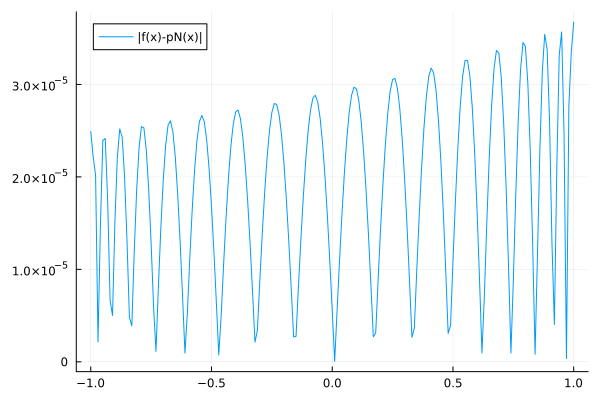

In [16]:
xr = -1.0:0.01:1.0
errors = [abs(f(t) - aN(t)) for t in xr]
plot(xr, errors, label="|f(x)-pN(x)|",legend=:topleft)

The largest error occurs at the end.

In [17]:
eN = abs(f(1.0) - aN(1.0))

3.675578409456648e-5

We need a polynomial of degree 19 to get four decimal places correct in the least squares approximation.

# Question 4

Purchasing new equipment for $\$10,000$ will give an annual savings
of $\$800$. 

Using annual compounding at an interest rate of 5\%,
how long should this new equipment last to justify its purchase?

## answer to question 4

The equation we want to solve is

$$
   10000 = 800 \sum_{k=1}^{N} \exp(-0.05k)
         = 800 \left( \frac{\exp(-0.05(N+1)) - 1}{\exp(-0.05) - 1} - 1 \right)
$$

where $N$ is the number of years we want the equipment to last.

In [18]:
"""
function f!(F, x)
defines F[1] as the input to nlsolve.
"""
function f!(F, x)
    N = x[1]
    F[1] = 10000 - 800*( (exp(-0.05*(N+1)) - 1)/(exp(-0.05) - 1) - 1)
end

f!

In [19]:
sol = nlsolve(f!, [10.0])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [10.0]
 * Zero: [20.48245847552222]
 * Inf-norm of residuals: 0.000000
 * Iterations: 5
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 6
 * Jacobian Calls (df/dx): 6

In [20]:
sum([exp(-0.05*k)*800 for k=1:21])

10143.137897754556

Indeed, if we compute the present values of the annual savings, then it takes 21 years till the sum of those present values exceeded the first costs.

# Question 5

Describe in one paragraph what you learned 
from *another* project presentation.